In [1]:
###　NMF_Alanysisi
#### Load a scv file aggregated from a specified website or local source and perform NMF.


===== W（サンプル×トピック）=====
            Topic1  Topic2  Topic3
Unnamed: 0                        
akke2        2.163   0.000   0.000
akke5        0.000   0.516   0.009
akke9        0.130   0.043   0.227
ataka2       1.766   0.014   0.000
ataka5       0.144   1.078   0.000
ataka9       0.203   0.114   0.214
kana2        0.998   0.059   0.009
kana5        0.295   1.312   0.000
kana9        0.000   0.000   3.446
kato2        2.646   0.000   0.000
kato5        0.000   1.926   0.000
kato9        0.049   0.048   0.342
kumi2        0.657   0.210   0.057
kumi5        0.160   1.042   0.002
kumi9        0.052   0.046   0.181
mari2        1.852   0.000   0.000
mari5        0.196   1.879   0.010
mari9        0.112   0.025   0.372
nogu2        1.842   0.226   0.055
nogu5        0.000   2.716   0.000
nogu9        0.109   0.049   0.218
oota2        0.444   0.139   0.029
oota5        0.070   1.854   0.000
oota9        0.124   0.023   0.277
ori2         1.328   0.000   0.000
ori5         0.148   0.135   0

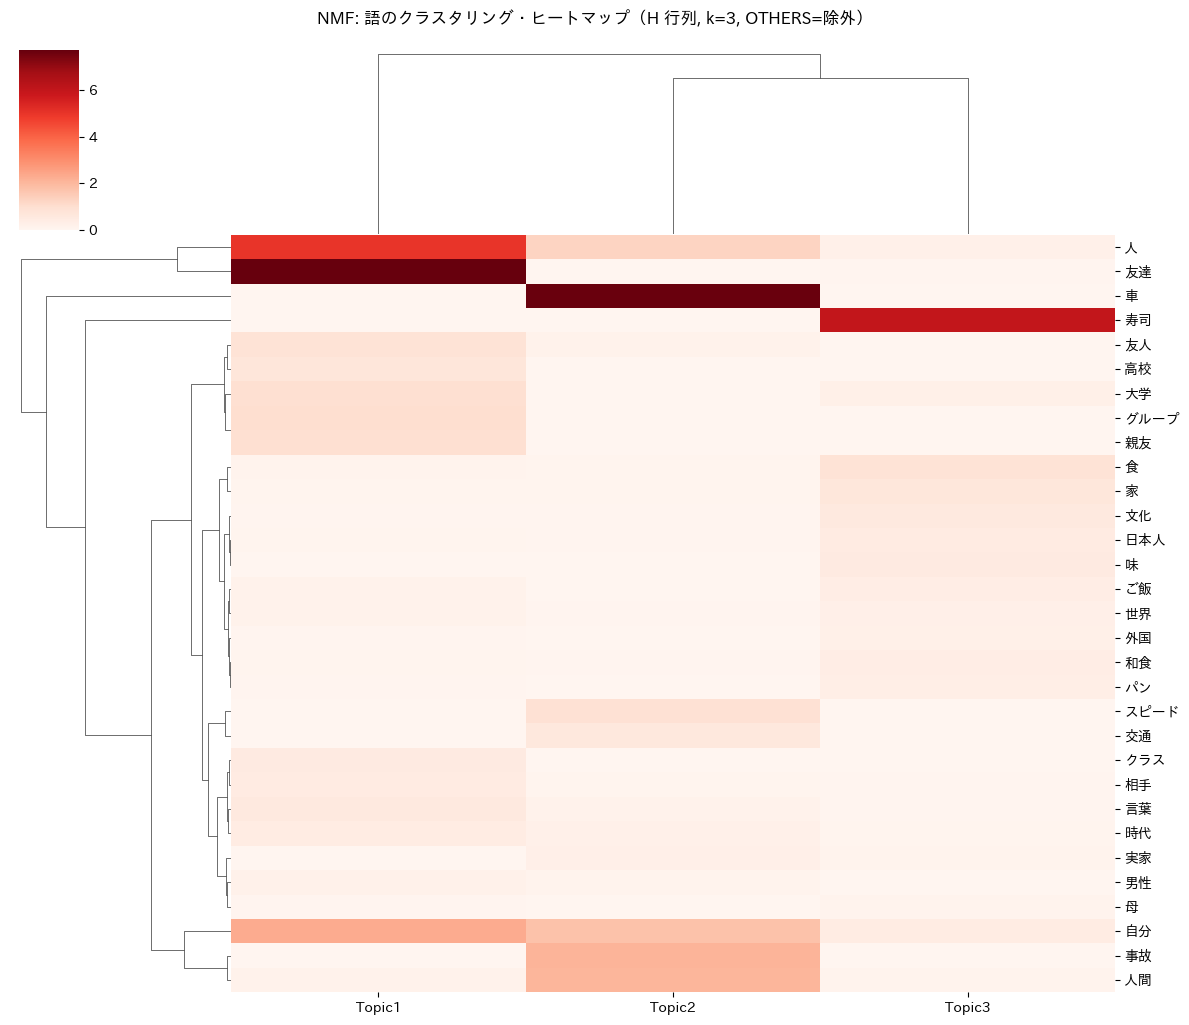

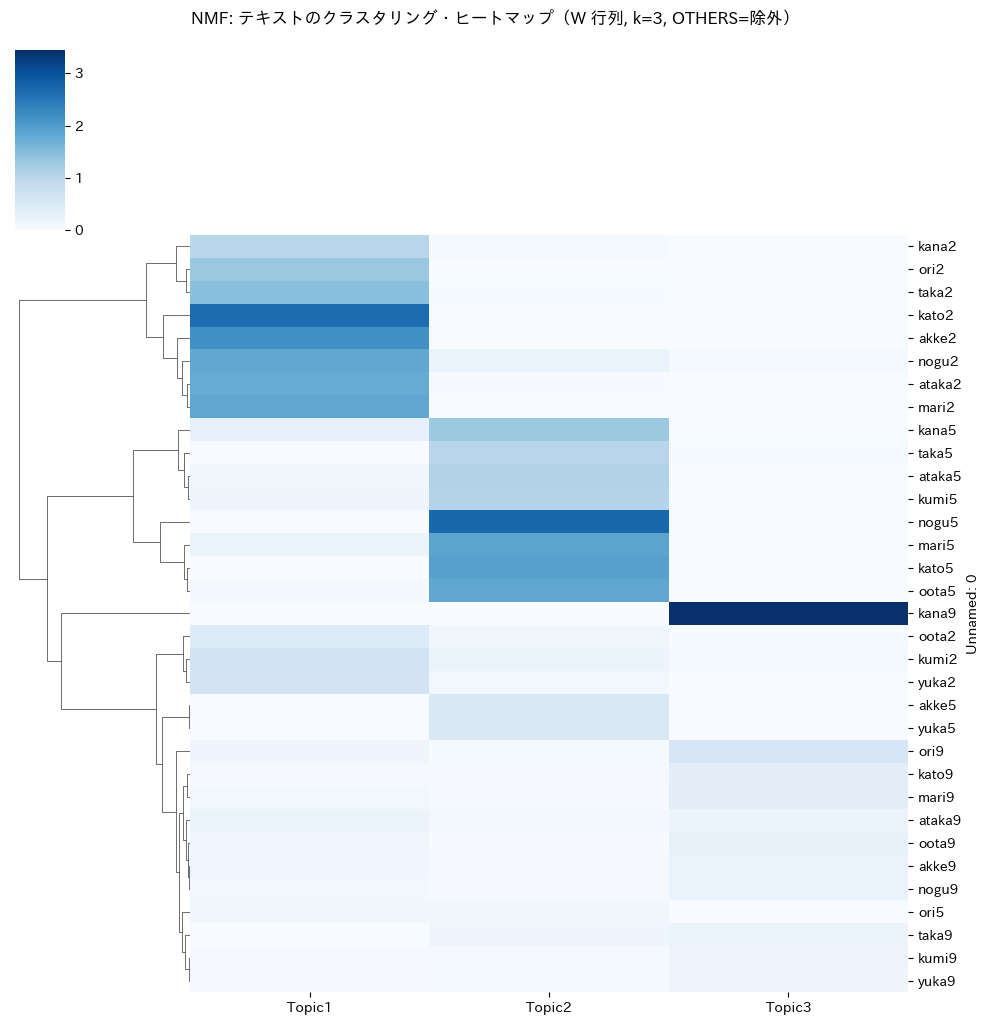

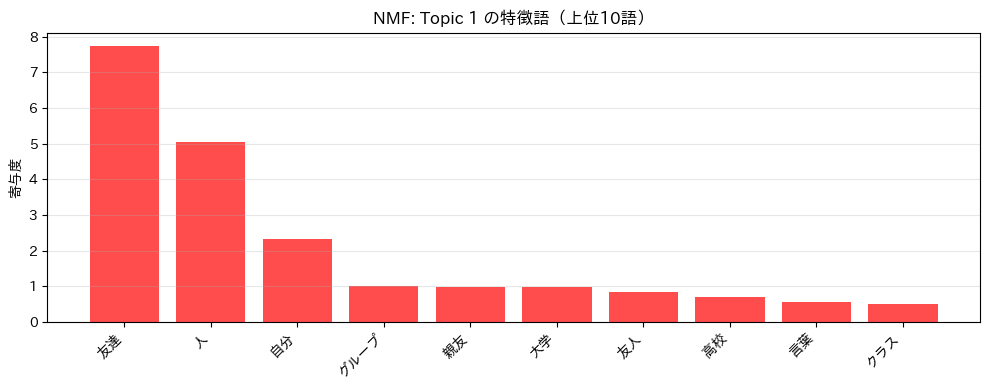

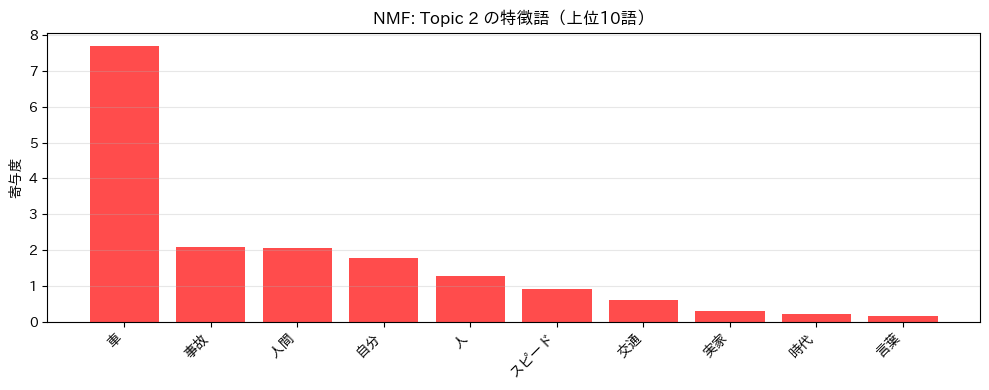

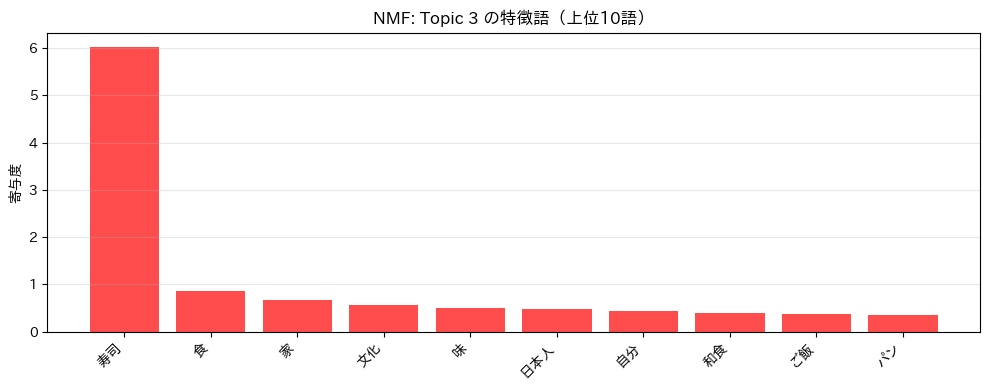

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
from sklearn.decomposition import NMF

# ============================================================
# 設定
# ============================================================
use_others = False     # True で OTHERS を使う / False で OTHERS を除外
k = 3  # NMF のトピック数（例：4）
linkage_method = "ward"   # 階層クラスタリングの手法

# --- データ読み込み ---
path = "https://www.iwanami.co.jp/files/moreinfo/0298960/sakubun3f.csv"
d1 = pd.read_csv(path, encoding="shift-jis")
# --- 第1列をドキュメントラベルとして index にする ---
doc_labels = d1.iloc[:, 0]
# --- 語彙データ（数値データ）を抽出: 第2列〜最後の1列前まで ---
X = d1.iloc[:, 1:]
# --- 行ラベルをドキュメント名に変更 ---
X.index = doc_labels
#X_rel = X.div(X.sum(axis=1), axis=0)

# ============================================================
# 集計したデータがdfの場合は、X = df.copy()の前の＃を削除してください
#X = df.copy()
# ============================================================

# OTHERS のオンオフ
if not use_others:
    X = X.drop(columns=["OTHERS"], errors="ignore")

# 非負行列にする（マイナス防止）
X = X.clip(lower=0)

# ============================================================
# NMF（非負行列因子分解）
# ============================================================
model = NMF(
    n_components=k,
    init="nndsvda",
    solver="cd",
    max_iter=500,
    random_state=0
)

W = model.fit_transform(X.values)    # shape = (n_samples, k)
H = model.components_                # shape = (k, n_terms)

# DataFrame で扱いやすく
W_df = pd.DataFrame(W, index=X.index, columns=[f"Topic{i+1}" for i in range(k)])
H_df = pd.DataFrame(H, index=[f"Topic{i+1}" for i in range(k)], columns=X.columns)

print("\n===== W（サンプル×トピック）=====")
print(W_df.round(3))
print("\n===== H（トピック×語）=====")
print(H_df.round(3))

# ============================================================
# 図示①：語 × トピック のクラスタリングヒートマップ（H 行列）
# ============================================================

sns.clustermap(
    H_df.T,               # 語 × トピック（行：語）
    method="ward",
    metric="euclidean",
    cmap="Reds",
    figsize=(12, 10),
    row_cluster=True,     # 語のクラスタリング
    col_cluster=True      # トピック側もクラスタリング（任意）
)

plt.suptitle(
    f"NMF: 語のクラスタリング・ヒートマップ（H 行列, k={k}, OTHERS={'使用' if use_others else '除外'}）",
    y=1.02
)
plt.show()

# ============================================================
# 図示②：サンプル × トピック のクラスタリングヒートマップ（W 行列）
# ============================================================

sns.clustermap(
    W_df,                 # サンプル × トピック
    method="ward",
    metric="euclidean",
    cmap="Blues",
    figsize=(10, 10),
    row_cluster=True,     # テキスト（行）のクラスタリング
    col_cluster=False     # トピック列はクラスタリングしない（意味維持）
)

plt.suptitle(
    f"NMF: テキストのクラスタリング・ヒートマップ（W 行列, k={k}, OTHERS={'使用' if use_others else '除外'}）",
    y=1.02
)
plt.show()

# ============================================================
# 図示③：各トピックの重要語（上位10語）
# ============================================================
for t in range(k):
    h_top = H_df.loc[f"Topic{t+1}"].sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 4))
    plt.bar(h_top.index, h_top.values, color="red", alpha=0.7)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("寄与度")
    plt.title(f"NMF: Topic {t+1} の特徴語（上位10語）")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
